In [3]:
%pip install numpy
%pip install missingno matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


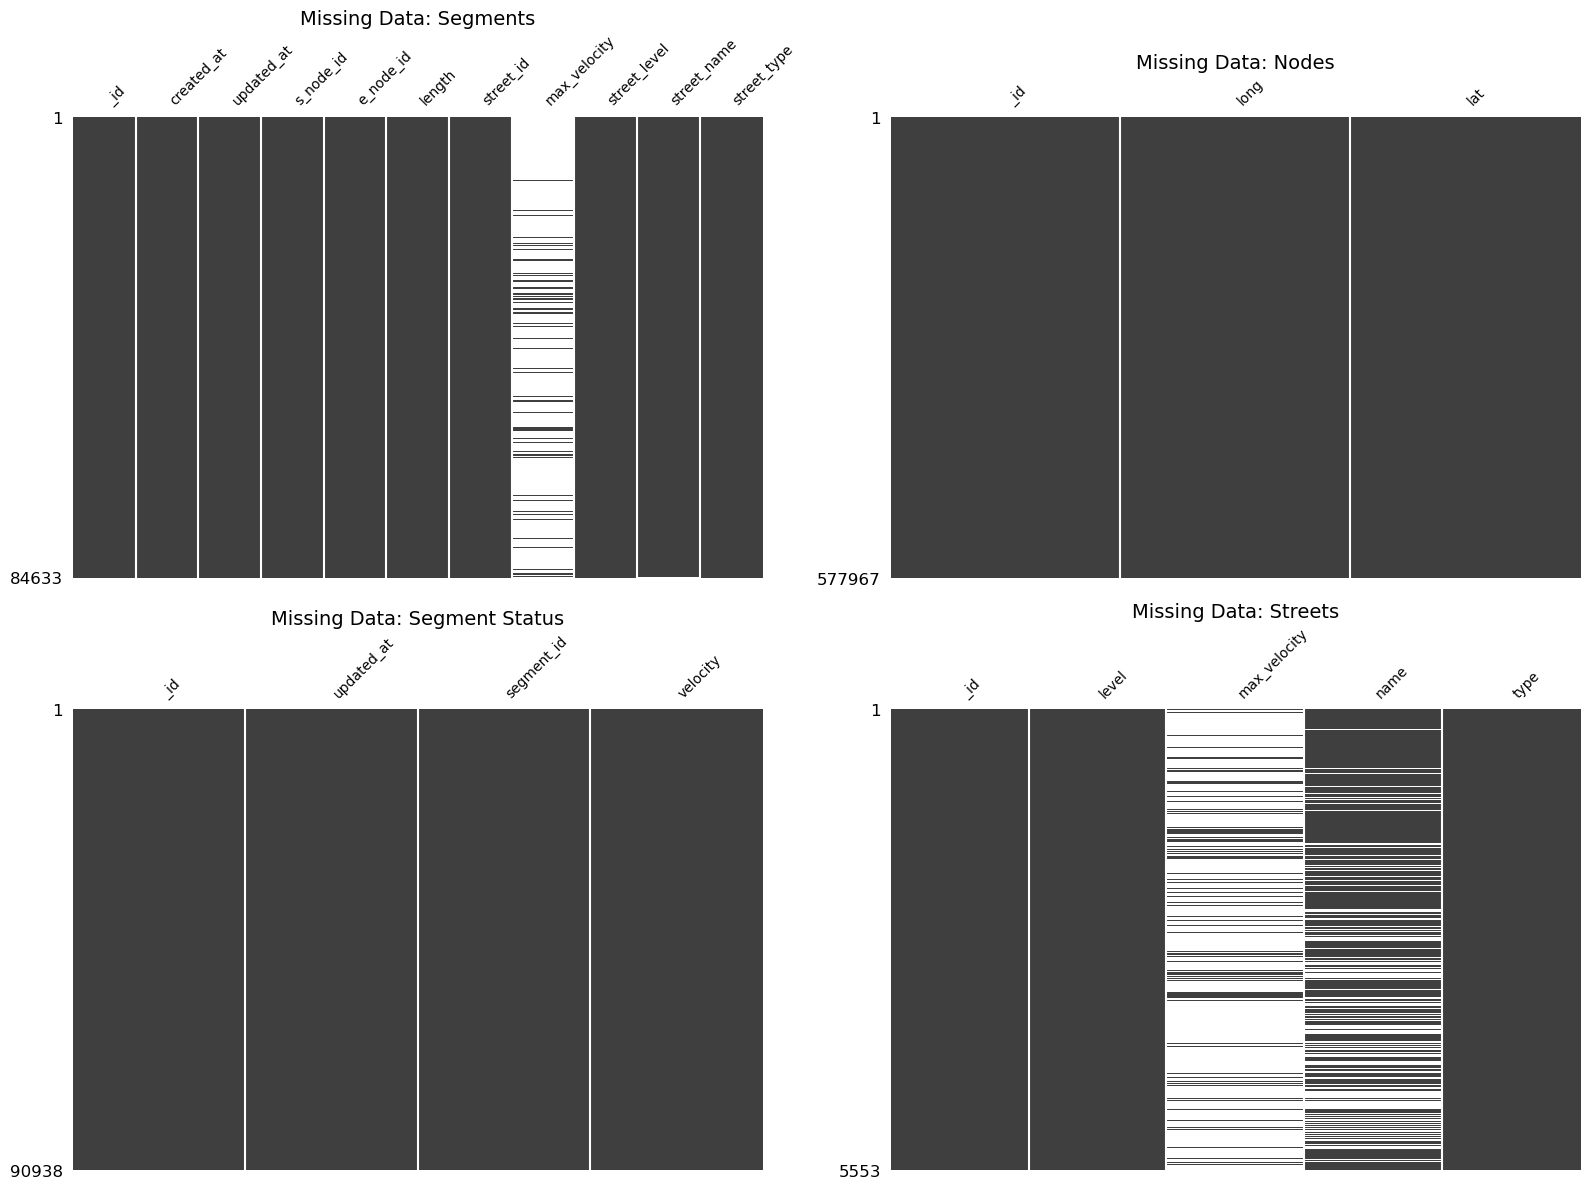

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

data_seg=pd.read_csv("./segments.csv")
data_node=pd.read_csv("./nodes.csv")
data_seg_stat=pd.read_csv("./segment_status.csv")
data_streets=pd.read_csv("./streets.csv")

# Check all dataset to find any nullable
# show missing values of data_streets
datasets = [
    (data_seg, "Segments"),
    (data_node, "Nodes"),
    (data_seg_stat, "Segment Status"),
    (data_streets, "Streets")
]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (df, name) in enumerate(datasets):
    msno.matrix(df, ax=axes_flat[i], sparkline=False, fontsize=10)
    axes_flat[i].set_title(f"Missing Data: {name}", fontsize=14)

plt.tight_layout()
plt.show()


In [2]:
# Check value from not nullable records
filtered_streets = data_streets.dropna(subset=['max_velocity']).drop_duplicates(subset=['level'], keep='first')
print("Danh sách các 'level' duy nhất kèm max_velocity:")
print(filtered_streets[['level', 'max_velocity']])

Danh sách các 'level' duy nhất kèm max_velocity:
     level  max_velocity
0        1          80.0
6        3          40.0
42       4          40.0
319      2          60.0


In [3]:
# Check column 'name'

# 1. Tách nhóm có name và nhóm bị missing name
has_name = data_streets[data_streets['name'].notna()][['_id', 'name']].drop_duplicates(subset=['_id'])
missing_name = data_streets[data_streets['name'].isna()].drop(columns=['name'])

# 2. Merge nhóm missing với nhóm có name dựa trên '_id'
merged = pd.merge(missing_name, has_name, on='_id', how='left', suffixes=('', '_matched'))

# 3. Phân loại dựa trên việc có tìm thấy name tương ứng hay không
matched_records = merged[merged['name'].notna()]
unmatched_records = merged[merged['name'].isna()]

# 4. Thống kê số lượng
count_matched = len(matched_records)
count_unmatched = len(unmatched_records)

print(f"Số lượng record missing có '_id' trùng với record có 'name': {count_matched}")
print(f"Số lượng record missing có '_id' KHÔNG trùng với record có 'name': {count_unmatched}")

# Bạn có thể xem chi tiết các tập dữ liệu này bằng cách gọi:
# matched_records (chứa các dòng có thể khôi phục lại tên dựa vào _id)
# unmatched_records (chứa các dòng mất tên hoàn toàn, _id không đối chiếu được)

Số lượng record missing có '_id' trùng với record có 'name': 0
Số lượng record missing có '_id' KHÔNG trùng với record có 'name': 1605


In [31]:
# check reference
bad_street_ids = data_streets[data_streets['name'].isna()]['_id']

print(f"Tổng số ID street cần kiểm tra xóa: {len(bad_street_ids)}\n")
print("--- KẾT QUẢ KIỂM TRA THAM CHIẾU Ở CÁC DATASET KHÁC ---")

# 2. Kiểm tra trong data_segments (Giả sử cột tham chiếu tên là 'street_id')
# Bạn hãy thay đổi tên cột 'street_id' cho đúng với thiết kế thực tế của file nếu cần
if 'street_id' in data_seg.columns:
    count_seg = data_seg['street_id'].isin(bad_street_ids).sum()
    print(f"* segments.csv: Có {count_seg} dòng đang tham chiếu đến các ID sắp xóa.")
else:
    print("* segments.csv: Không tìm thấy cột chứa ID của streets.")

# 3. Kiểm tra trong data_nodes (Giả sử cột tham chiếu tên là 'street_id')
if 'street_id' in data_node.columns:
    count_node = data_node['street_id'].isin(bad_street_ids).sum()
    print(f"* nodes.csv: Có {count_node} dòng đang tham chiếu đến các ID sắp xóa.")
else:
    print("* nodes.csv: Không tìm thấy cột chứa ID của streets.")

# 4. Kiểm tra trong data_segment_status (Giả sử cột tham chiếu tên là 'street_id')
if 'street_id' in data_seg_stat.columns:
    count_stat = data_seg_stat['street_id'].isin(bad_street_ids).sum()
    print(f"* segment_status.csv: Có {count_stat} dòng đang tham chiếu đến các ID sắp xóa.")
else:
    print("* segment_status.csv: Không tìm thấy cột chứa ID của streets.")

Tổng số ID street cần kiểm tra xóa: 0

--- KẾT QUẢ KIỂM TRA THAM CHIẾU Ở CÁC DATASET KHÁC ---
* segments.csv: Có 0 dòng đang tham chiếu đến các ID sắp xóa.
* nodes.csv: Không tìm thấy cột chứa ID của streets.
* segment_status.csv: Không tìm thấy cột chứa ID của streets.


In [32]:
if 'street_id' in data_seg.columns:
    data_seg = data_seg[~data_seg['street_id'].isin(bad_street_ids)]

if 'street_id' in data_node.columns:
    data_node = data_node[~data_node['street_id'].isin(bad_street_ids)]

if 'street_id' in data_seg_stat.columns:
    data_seg_stat = data_seg_stat[~data_seg_stat['street_id'].isin(bad_street_ids)]

# 4. Xóa các dòng bị missing name ở bảng gốc streets
data_streets = data_streets.dropna(subset=['name']).copy();

# 5. Lưu đè lại toàn bộ các file sau khi đã làm sạch
#data_streets.to_csv("../refined/streets.csv", index=False)
#data_seg.to_csv("../refined/segments.csv", index=False)
#data_node.to_csv("../refined/nodes.csv", index=False)
#data_seg_stat.to_csv("../refined/segment_status.csv", index=False)

print("Đã hoàn thành việc xóa cascade và cập nhật lại toàn bộ các file dữ liệu.")

Đã hoàn thành việc xóa cascade và cập nhật lại toàn bộ các file dữ liệu.


In [10]:
# re-fill missing data
speed_map = {
    1: 80.0,
    2: 60.0,
    3: 40.0,
    4: 40.0
}

print("Filling data")

# 1. Sử dụng .loc để điền khuyết cho data_streets một cách an toàn
data_streets.loc[:, 'max_velocity'] = data_streets['max_velocity'].fillna(data_streets['level'].map(speed_map))

# 2. Tạo bảng tra cứu tốc độ từ data_streets (sử dụng đúng cột '_id' như code của bạn)
street_speed_lookup = data_streets.set_index('_id')['max_velocity']

# 3. Sử dụng .loc để điền khuyết cho data_seg nhằm triệt tiêu hoàn toàn SettingWithCopyWarning
data_seg.loc[:, 'max_velocity'] = data_seg['max_velocity'].fillna(data_seg['street_id'].map(street_speed_lookup))

print("Filled successfully")

# Lưu cả 2 file sau khi xử lý khuyết dòng
# data_streets.to_csv("../refined/streets.csv", index=False)
# data_seg.to_csv("../refined/segments.csv", index=False)

Filling data
Filled successfully


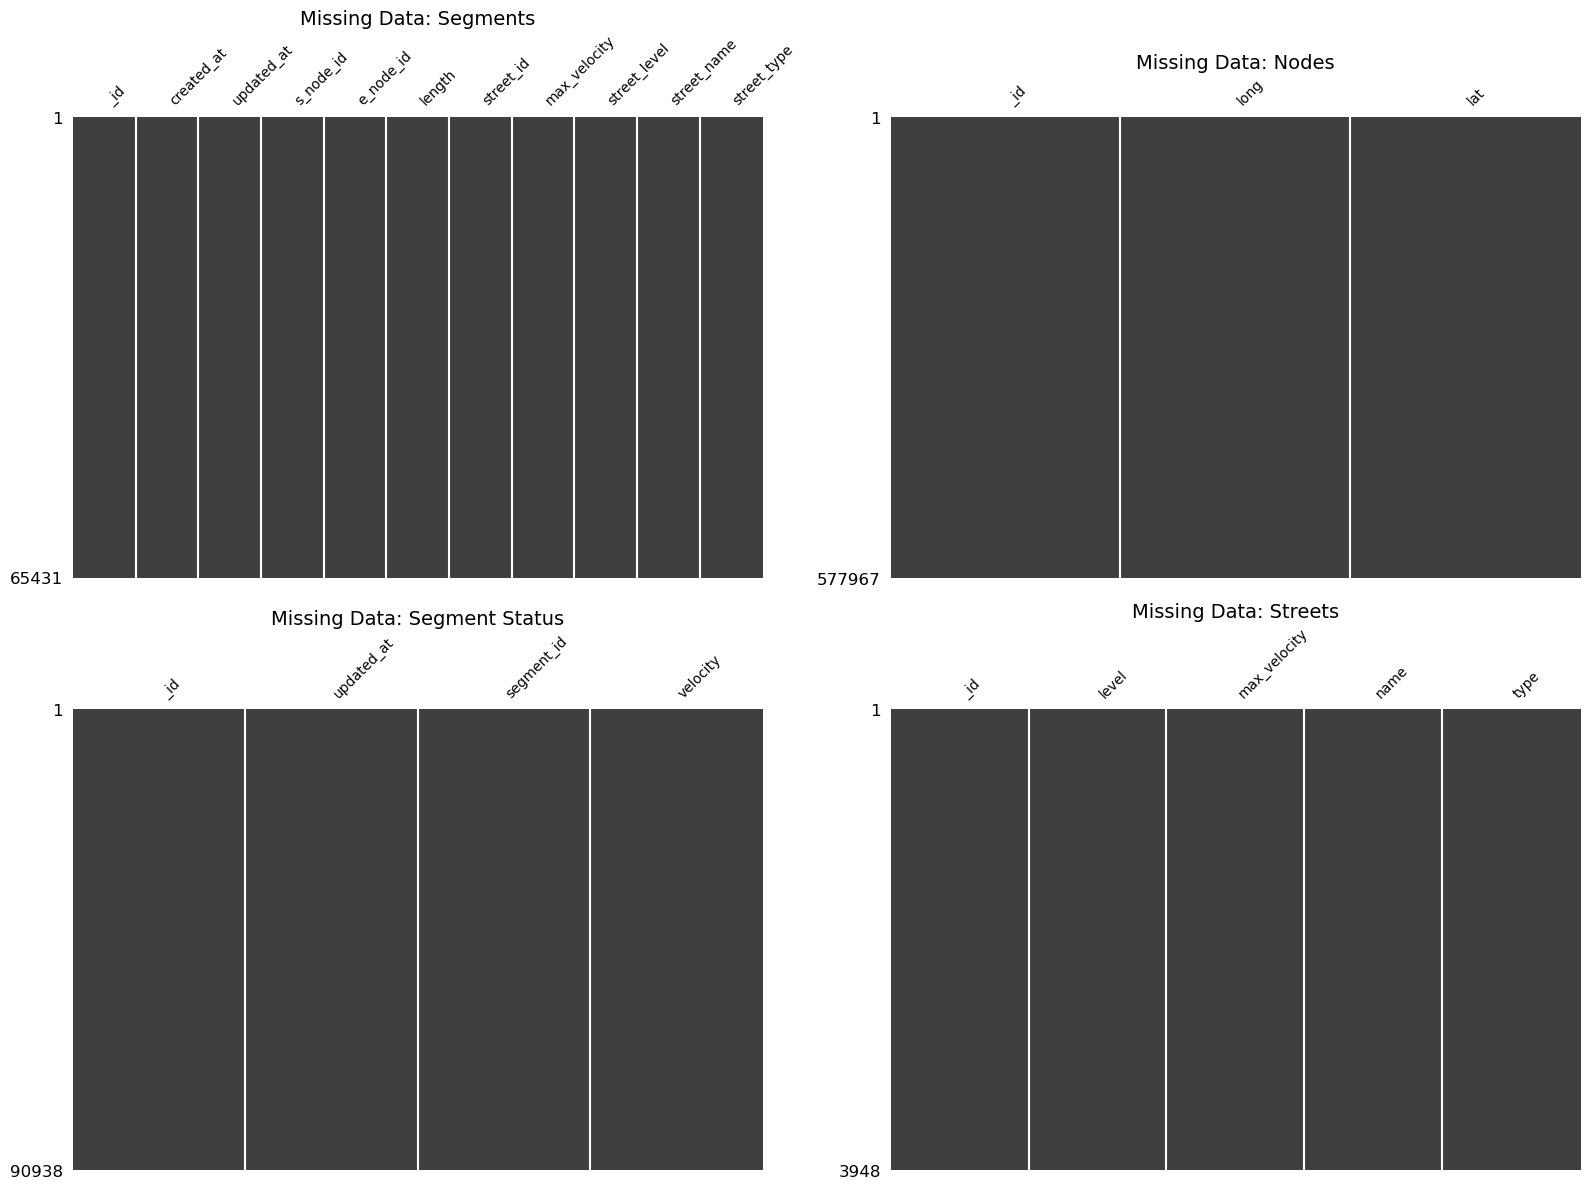

In [36]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

data_seg=pd.read_csv("../refined/segments.csv")
data_node=pd.read_csv("../refined/nodes.csv")
data_seg_stat=pd.read_csv("../refined/segment_status.csv")
data_streets=pd.read_csv("../refined/streets.csv")

# Check all dataset to find any nullable
# show missing values of data_streets
datasets = [
    (data_seg, "Segments"),
    (data_node, "Nodes"),
    (data_seg_stat, "Segment Status"),
    (data_streets, "Streets")
]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (df, name) in enumerate(datasets):
    msno.matrix(df, ax=axes_flat[i], sparkline=False, fontsize=10)
    axes_flat[i].set_title(f"Missing Data: {name}", fontsize=14)

plt.tight_layout()
plt.show()


--- THỐNG KÊ TÍNH LIÊN TỤC CỦA THỜI GIAN (UPDATED_AT) ---
gap_category
Dòng đầu tiên        10027
Dưới 15 phút         60955
Đúng 15 phút             0
Từ 15 - 30 phút       2279
Đúng 30 phút             0
Bị lệch > 30 phút    17677
Name: count, dtype: int64

[CẢNH BÁO] Phát hiện 17677 khoảng trống dữ liệu lớn hơn 30 phút!
       segment_id                       updated_at  time_gap_minutes
87574          67 2021-03-23 09:59:46.821000+00:00      20170.490750
76046         173 2020-12-28 07:31:35.735000+00:00        152.383750
74597         175 2020-12-27 03:20:59.464000+00:00      25275.707750
74789         175 2020-12-27 04:06:26.471000+00:00         45.450117
74948         177 2020-12-27 04:51:58.479000+00:00      25318.993200


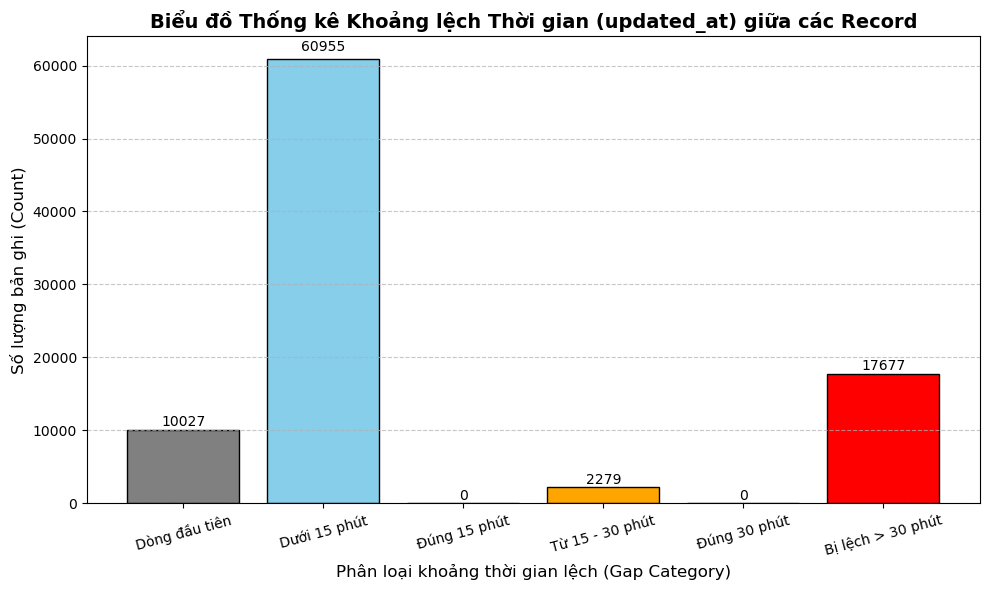

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Giả sử bạn đã chạy các bước ép kiểu datetime và tính 'time_gap_minutes' ở trên
# data_seg_stat = pd.read_csv("data/segment_status.csv")
data_seg_stat['updated_at'] = pd.to_datetime(data_seg_stat['updated_at'])
data_seg_stat = data_seg_stat.sort_values(by=['segment_id', 'updated_at'])
data_seg_stat['time_gap_minutes'] = data_seg_stat.groupby('segment_id')['updated_at'].diff().dt.total_seconds() / 60

# 1. Phân loại độ lệch vào các nhóm
bins = [-np.inf, 0, 14.99, 15.01, 29.99, 30.01, np.inf]
labels = ['Dòng đầu tiên', 'Dưới 15 phút', 'Đúng 15 phút', 'Từ 15 - 30 phút', 'Đúng 30 phút', 'Bị lệch > 30 phút']
gap_series = data_seg_stat['time_gap_minutes'].fillna(-1) 
data_seg_stat['gap_category'] = pd.cut(gap_series, bins=bins, labels=labels)

# 2. Lấy dữ liệu thống kê số lượng
gap_counts = data_seg_stat['gap_category'].value_counts().reindex(labels)

print("--- THỐNG KÊ TÍNH LIÊN TỤC CỦA THỜI GIAN (UPDATED_AT) ---")
print(gap_counts)

# 3. SỬA LỖI: Trích xuất các bản ghi bị lệch nghiêm trọng bằng .head()
bad_gaps = data_seg_stat[data_seg_stat['time_gap_minutes'] > 30]
if not bad_gaps.empty:
    print(f"\n[CẢNH BÁO] Phát hiện {len(bad_gaps)} khoảng trống dữ liệu lớn hơn 30 phút!")
    print(bad_gaps[['segment_id', 'updated_at', 'time_gap_minutes']].head(5)) # Đã sửa thành .head(5)

# 4. VẼ ĐỒ THỊ TRỰC QUAN HÓA
plt.figure(figsize=(10, 6))
# Vẽ biểu đồ cột với màu sắc nổi bật cho phần bị lệch
colors = ['gray', 'skyblue', 'green', 'orange', 'blue', 'red']
bars = plt.bar(gap_counts.index, gap_counts.values, color=colors, edgecolor='black')

# Hiển thị số liệu cụ thể trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{int(yval)}', ha='center', va='bottom', fontsize=10)

plt.title("Biểu đồ Thống kê Khoảng lệch Thời gian (updated_at) giữa các Record", fontsize=14, fontweight='bold')
plt.xlabel("Phân loại khoảng thời gian lệch (Gap Category)", fontsize=12)
plt.ylabel("Số lượng bản ghi (Count)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

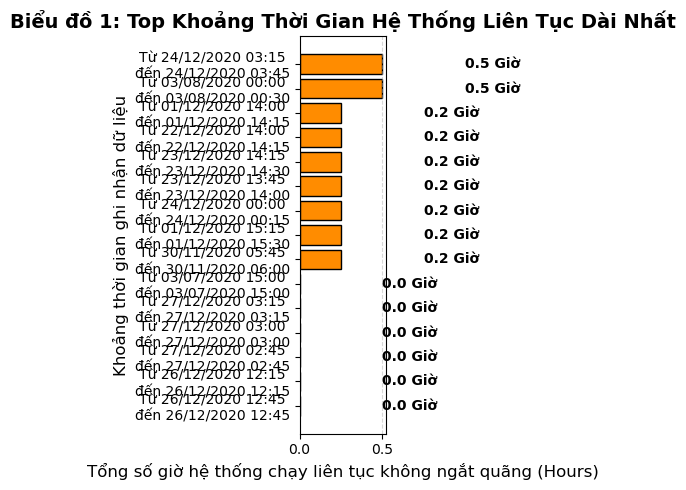

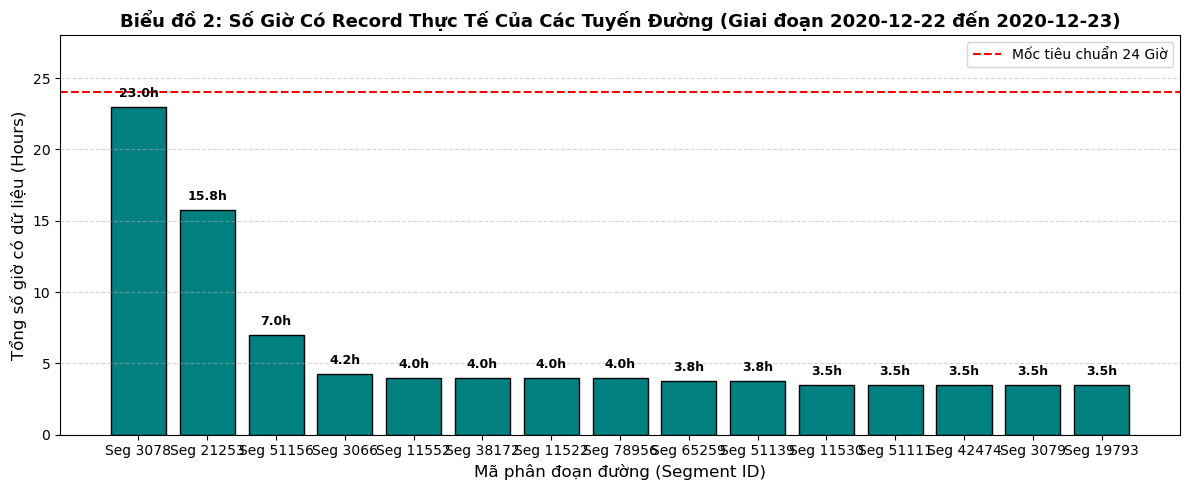

Thống kê: Có 0 tuyến đường có tổng lượng record tích lũy đạt trên 24 giờ trong 2 ngày này.


In [33]:
data_seg_stat['updated_at'] = pd.to_datetime(data_seg_stat['updated_at']).dt.tz_localize(None)
data_seg_stat['time_slot'] = data_seg_stat['updated_at'].dt.round('15Min')

total_segments = data_seg_stat['segment_id'].nunique()

# Đếm số lượng segment hoạt động tại mỗi time_slot
timeline = data_seg_stat.groupby('time_slot')['segment_id'].nunique().reset_index()
timeline.columns = ['time_slot', 'active_segments_count']
timeline = timeline.sort_values('time_slot')

# Tính khoảng cách giữa các time_slot liên tiếp (phút)
timeline['gap_minutes'] = timeline['time_slot'].diff().dt.total_seconds() / 60

# Ngưỡng tối thiểu 1% tổng số tuyến đường xuất hiện đồng thời
threshold_segments = int(total_segments * 0.01) 
is_broken = (timeline['gap_minutes'] > 15) | (timeline['active_segments_count'] < threshold_segments)

# Đánh dấu Block ID
timeline['system_block_id'] = is_broken.cumsum()

# Thống kê độ dài từng Block theo Giờ (Hours)
system_blocks = timeline.groupby('system_block_id').agg(
    start_date=('time_slot', 'min'),
    end_date=('time_slot', 'max'),
    total_slots=('time_slot', 'count')
).reset_index()

system_blocks['duration_hours'] = (system_blocks['end_date'] - system_blocks['start_date']).dt.total_seconds() / 3600
longest_system_windows = system_blocks.sort_values(by='duration_hours', ascending=False).head(15)

# ==========================================
# BIỂU ĐỒ 1: CHUỖI NGÀY LIÊN TỤC CỦA HỆ THỐNG (TÍNH THEO GIỜ)
# ==========================================
plt.figure(figsize=(12, 5))

y_labels_sys = [f"Từ {row['start_date'].strftime('%d/%m/%Y %H:%M')} \nđến {row['end_date'].strftime('%d/%m/%Y %H:%M')}" 
                for _, row in longest_system_windows.iterrows()]

bars_sys = plt.barh(y_labels_sys[::-1], longest_system_windows['duration_hours'].values[::-1], color='darkorange', edgecolor='black')

for bar in bars_sys:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f} Giờ', ha='left', va='center', fontsize=10, fontweight='bold')

plt.title("Biểu đồ 1: Top Khoảng Thời Gian Hệ Thống Liên Tục Dài Nhất", fontsize=14, fontweight='bold')
plt.xlabel("Tổng số giờ hệ thống chạy liên tục không ngắt quãng (Hours)", fontsize=12)
plt.ylabel("Khoảng thời gian ghi nhận dữ liệu", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# ==========================================
# XỬ LÝ DỮ LIỆU CHO BIỂU ĐỒ 2 (CHECK CHUỖI RECORD THEO TUYẾN ĐƯỜNG)
# Lọc lấy khoảng dữ liệu từ 22/12/2020 đến 23/12/2020 như bạn đã chọn
# ==========================================
start_target = '2020-12-22 00:00:00'
end_target = '2020-12-23 23:45:00'

df_target_days = data_seg_stat[
    (data_seg_stat['time_slot'] >= start_target) & 
    (data_seg_stat['time_slot'] <= end_target)
]

# Đếm số lượng record (time slots) thực tế của từng tuyến đường đơn lẻ
segment_counts = df_target_days.groupby('segment_id').size().reset_index(name='slots_count')

# Quy đổi số lượng record sang số giờ hoạt động thực tế (mỗi record = 15 phút = 0.25 giờ)
segment_counts['actual_hours'] = segment_counts['slots_count'] * 0.25

# Lấy top 15 tuyến đường có chuỗi record đầy đủ và dài nhất trong 2 ngày này
top_segments = segment_counts.sort_values(by='actual_hours', ascending=False).head(15)


# ==========================================
# BIỂU ĐỒ 2: CHUỖI RECORD ĐỦ >24H THEO TỪNG TUYẾN ĐƯỜNG ĐƠN LẺ
# ==========================================
plt.figure(figsize=(12, 5))

# Đổi mã ID thành dạng chuỗi để vẽ đồ thị cột đứng
x_labels_seg = [f"Seg {int(sid)}" for sid in top_segments['segment_id']]

bars_seg = plt.bar(x_labels_seg, top_segments['actual_hours'].values, color='teal', edgecolor='black')

# Kẻ đường giới hạn mốc 24 giờ tiêu chuẩn để bạn dễ đối chiếu
plt.axhline(y=24, color='red', linestyle='--', linewidth=1.5, label='Mốc tiêu chuẩn 24 Giờ')

for bar in bars_seg:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title(f"Biểu đồ 2: Số Giờ Có Record Thực Tế Của Các Tuyến Đường (Giai đoạn {start_target[:10]} đến {end_target[:10]})", fontsize=13, fontweight='bold')
plt.xlabel("Mã phân đoạn đường (Segment ID)", fontsize=12)
plt.ylabel("Tổng số giờ có dữ liệu (Hours)", fontsize=12)
plt.ylim(0, top_segments['actual_hours'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# In thống kê số lượng đường vượt qua mốc 24h để train model demo
qualified_count = len(segment_counts[segment_counts['actual_hours'] >= 24])
print(f"Thống kê: Có {qualified_count} tuyến đường có tổng lượng record tích lũy đạt trên 24 giờ trong 2 ngày này.")

In [34]:
data_seg_stat['updated_at'] = pd.to_datetime(data_seg_stat['updated_at']).dt.tz_localize(None)

# Làm tròn thời gian về mốc 15 phút chuẩn
data_seg_stat['time_slot'] = data_seg_stat['updated_at'].dt.round('15Min')

# ----------------------------------------------------------------------
# BƯỚC SỬA LỖI CHÍ MẠNG: Gom nhóm loại bỏ trùng lặp mốc thời gian của từng segment
# Lấy giá trị trung bình (mean) của các thuộc tính số nếu tại mốc đó có nhiều record phát sinh
data_seg_stat_unique = data_seg_stat.groupby(['segment_id', 'time_slot']).mean(numeric_only=True).reset_index()
# ----------------------------------------------------------------------

# Sắp xếp lại thứ tự theo tuyến đường và thời gian tăng dần
data_seg_stat_unique = data_seg_stat_unique.sort_values(by=['segment_id', 'time_slot'])

# 2. Tính khoảng cách thời gian thực tế giữa các mốc (bây giờ tối thiểu sẽ là 15 phút)
data_seg_stat_unique['gap_minutes'] = data_seg_stat_unique.groupby('segment_id')['time_slot'].diff().dt.total_seconds() / 60

# Đánh dấu đứt gãy nếu khoảng cách > 15 phút hoặc là dòng đầu tiên (NaN)
is_broken = (data_seg_stat_unique['gap_minutes'] > 15) | (data_seg_stat_unique['gap_minutes'].isna())

# 3. Tạo ID cho từng chuỗi liên tục thực tế
data_seg_stat_unique['segment_block_id'] = is_broken.groupby(data_seg_stat_unique['segment_id']).cumsum()

# 4. Gom nhóm thống kê chi tiết từng chuỗi
block_summary = data_seg_stat_unique.groupby(['segment_id', 'segment_block_id']).agg(
    start_time=('time_slot', 'min'),
    end_time=('time_slot', 'max'),
    record_count=('time_slot', 'count') # Bây giờ record_count chính là số lượng slot 15p thực tế
).reset_index()

# Tính số giờ liên tục thực tế từ mốc bắt đầu đến mốc kết thúc
block_summary['duration_hours'] = (block_summary['end_time'] - block_summary['start_time']).dt.total_seconds() / 3600

# 5. LỌC CHUẨN: Chỉ lấy các chuỗi liên tục thực sự >= 24 giờ (tương đương có ít nhất 96 slots liên tục)
qualified_sequences = block_summary[block_summary['duration_hours'] >= 24].sort_values(by='duration_hours', ascending=False)

# 6. In kết quả kiểm đếm chính xác
print("--- KẾT QUẢ TÌM KIẾM CHUỖI LIÊN TỤC ĐỦ 24H (ĐÃ SỬA LỖI TRÙNG LẶP) ---")
print(f"Tìm thấy TỔNG CỘNG {len(qualified_sequences)} chuỗi đạt tiêu chuẩn liên tục thực tế >= 24 tiếng.\n")

if not qualified_sequences.empty:
    print("Top 10 chuỗi liên tục dài nhất thực tế để train model:")
    print(qualified_sequences[['segment_id', 'start_time', 'end_time', 'duration_hours', 'record_count']].head(10).to_string(index=False))
else:
    print("[CẢNH BÁO] Không có bất kỳ phân đoạn đơn lẻ nào có dữ liệu chạy liên tục không nghỉ đủ 24 tiếng!")

--- KẾT QUẢ TÌM KIẾM CHUỖI LIÊN TỤC ĐỦ 24H (ĐÃ SỬA LỖI TRÙNG LẶP) ---
Tìm thấy TỔNG CỘNG 0 chuỗi đạt tiêu chuẩn liên tục thực tế >= 24 tiếng.

[CẢNH BÁO] Không có bất kỳ phân đoạn đơn lẻ nào có dữ liệu chạy liên tục không nghỉ đủ 24 tiếng!


In [28]:

# 2. Lọc toàn bộ record của segment_id bằng 3078 và tạo bản sao độc lập
segment_3078_data = data_seg_stat[data_seg_stat['segment_id'] == 3078].copy()

# 3. Sắp xếp lại theo thứ tự thời gian tăng dần để dễ theo dõi chuỗi liên tục
segment_3078_data['updated_at'] = pd.to_datetime(segment_3078_data['updated_at'])
segment_3078_data = segment_3078_data.sort_values(by='updated_at')

# 4. Kiểm tra số lượng bản ghi thu được
print(f"Tổng số record tìm thấy của segment 3078: {len(segment_3078_data)}")

# Hiển thị 10 dòng đầu tiên của phân đoạn này
print("\nDữ liệu mẫu của segment 3078:")
print(segment_3078_data.head(10))

Tổng số record tìm thấy của segment 3078: 673

Dữ liệu mẫu của segment 3078:
         _id              updated_at  segment_id  velocity  time_gap_minutes  \
39519  39519 2020-11-16 14:16:18.163        3078        25               NaN   
40488  40488 2020-11-19 11:57:32.839        3078        28       4181.244600   
43581  43581 2020-11-27 14:18:39.333        3078        29      11661.108233   
44356  44356 2020-11-29 02:59:57.282        3078        49       2201.299150   
48162  48162 2020-12-01 12:25:29.632        3078        23       3445.539167   
62986  62986 2020-12-15 11:35:52.527        3078        22      20110.381583   
66167  66167 2020-12-21 15:02:26.296        3078        34       8846.562817   
66353  66353 2020-12-21 15:31:05.174        3078        34         28.647967   
66539  66539 2020-12-21 15:59:50.889        3078        34         28.761917   
66786  66786 2020-12-22 13:38:18.463        3078        35       1298.459567   

            gap_category  continuous_block

In [35]:
data_seg_stat['updated_at'] = pd.to_datetime(data_seg_stat['updated_at']).dt.tz_localize(None)

# Làm tròn thời gian về mốc 15 phút để chuẩn hóa
data_seg_stat['time_slot'] = data_seg_stat['updated_at'].dt.round('15Min')

# 2. Lọc lấy toàn bộ record từ ngày 01/08/2020 đến hết ngày 16/08/2020
start_date = '2020-08-01 00:00:00'
end_date = '2020-08-16 23:59:59'
df_august = data_seg_stat[(data_seg_stat['time_slot'] >= start_date) & (data_seg_stat['time_slot'] <= end_date)].copy()

print(f"Tổng số bản ghi thô thu được từ ngày 1/8 đến 16/8: {len(df_august)}")

if not df_august.empty:
    # 3. SỬA LỖI TRÙNG LẶP: Gom nhóm lấy giá trị duy nhất cho mỗi mốc 15 phút của từng segment
    df_august_unique = df_august.groupby(['segment_id', 'time_slot']).mean(numeric_only=True).reset_index()
    df_august_unique = df_august_unique.sort_values(by=['segment_id', 'time_slot'])
    
    # 4. Tính khoảng cách phút giữa các record liên tiếp của cùng một con đường
    df_august_unique['gap_minutes'] = df_august_unique.groupby('segment_id')['time_slot'].diff().dt.total_seconds() / 60
    
    # Đánh dấu đứt gãy nếu lệch > 15 phút hoặc là dòng đầu tiên của segment
    is_broken = (df_august_unique['gap_minutes'] > 15) | (df_august_unique['gap_minutes'].isna())
    
    # 5. Đánh dấu mã số nhóm (Block ID) cho các chuỗi liên tục thực tế
    df_august_unique['segment_block_id'] = is_broken.groupby(df_august_unique['segment_id']).cumsum()
    
    # 6. Gom nhóm đo lường độ dài của từng chuỗi dữ liệu liên tục
    block_summary = df_august_unique.groupby(['segment_id', 'segment_block_id']).agg(
        start_time=('time_slot', 'min'),
        end_time=('time_slot', 'max'),
        record_count=('time_slot', 'count')
    ).reset_index()
    
    # Quy đổi khoảng cách thời gian sang đơn vị Giờ (Hours)
    block_summary['duration_hours'] = (block_summary['end_time'] - block_summary['start_time']).dt.total_seconds() / 3600
    
    # Lọc lấy các chuỗi đạt tiêu chuẩn tối thiểu là chuỗi chu kỳ (ví dụ >= 6 tiếng hoặc chỉnh thành 24 tùy bạn)
    # Ở đây lọc các chuỗi thực sự có liên tục để sắp xếp
    longest_august_blocks = block_summary.sort_values(by='duration_hours', ascending=False)
    
    print("\n--- THỐNG KÊ TÍNH LIÊN TỤC TRONG GIAI ĐOẠN 1/8 - 16/8 ---")
    print(f"Số lượng chuỗi liên tục độc lập tìm thấy: {len(longest_august_blocks)}")
    
    print("\nTop 10 chuỗi liên tục dài nhất thực tế trong nửa đầu tháng 8:")
    print(longest_august_blocks[['segment_id', 'start_time', 'end_time', 'duration_hours', 'record_count']].head(10).to_string(index=False))
    
    # Kiểm tra nhanh xem có đoạn nào đạt đủ 24 tiếng liên tục không
    standard_24h = longest_august_blocks[longest_august_blocks['duration_hours'] >= 24]
    print(f"\nSố lượng segment có chuỗi record liên tục ĐỦ 24 TIẾNG TRỞ LÊN: {len(standard_24h)}")
    
else:
    print("[CẢNH BÁO] Không tìm thấy bất kỳ dữ liệu nào trong khoảng thời gian yêu cầu!")

Tổng số bản ghi thô thu được từ ngày 1/8 đến 16/8: 37452

--- THỐNG KÊ TÍNH LIÊN TỤC TRONG GIAI ĐOẠN 1/8 - 16/8 ---
Số lượng chuỗi liên tục độc lập tìm thấy: 3670

Top 10 chuỗi liên tục dài nhất thực tế trong nửa đầu tháng 8:
 segment_id          start_time            end_time  duration_hours  record_count
      21263 2020-08-05 01:45:00 2020-08-05 04:30:00            2.75            12
      47407 2020-08-10 02:00:00 2020-08-10 03:15:00            1.25             6
      21262 2020-08-05 03:00:00 2020-08-05 04:00:00            1.00             5
      55880 2020-08-03 00:00:00 2020-08-03 00:30:00            0.50             3
      55869 2020-08-03 00:00:00 2020-08-03 00:30:00            0.50             3
      55870 2020-08-03 00:00:00 2020-08-03 00:30:00            0.50             3
      55871 2020-08-03 00:00:00 2020-08-03 00:30:00            0.50             3
      55872 2020-08-03 00:00:00 2020-08-03 00:30:00            0.50             3
      55873 2020-08-03 00:00:00 2020